# 01 — Design Principles
**References:** Fisher (1935) · Cox & Reid (2000) *Theory of the Design of Experiments*

## Narrative thread
```
Why design matters -> Fisher's 3 principles -> Orthogonality -> Estimability -> Design efficiency
```

## Fisher's three principles

**1. Replication** — repeat each treatment on multiple experimental units.
- Provides an estimate of experimental error $\hat{\sigma}^2$
- Increases power by reducing $SE = \sigma/\sqrt{r}$
- Without replication, you cannot distinguish treatment effect from noise

**2. Randomization** — assign treatments to units at random.
- Eliminates systematic bias from unknown confounders
- Validates the use of probability models for inference
- Protects against the experimenter's unconscious bias

**3. Local control (blocking)** — group units into homogeneous blocks; randomize within blocks.
- Removes known sources of variation from the error term
- A properly blocked experiment is more powerful than an unblocked one
- "Block what you can, randomize what you cannot" — Box, Hunter & Hunter

## Key concepts

### Experimental unit vs observational unit
- **Experimental unit:** the entity to which the treatment is applied (e.g., a field plot, a user)
- **Observational unit:** the entity on which the outcome is measured (may differ — e.g., plants within a plot)
- Confusing these leads to **pseudoreplication** — inflated degrees of freedom and anticonservative tests

### Orthogonality
A design is **orthogonal** if all treatment contrasts are uncorrelated — each factor's effect can be estimated independently.

For a two-factor design with factors $A$ and $B$:
$$\text{Orthogonal} \iff \mathbf{x}_A^\top \mathbf{x}_B = 0$$

Orthogonality ensures: (1) estimates are uncorrelated, (2) adding/removing a factor doesn't change other estimates, (3) maximum efficiency.

### Estimability
A parameter combination $c^\top \beta$ is **estimable** if it can be expressed as a linear combination of the expected responses. In practice: a treatment contrast is estimable only if it appears in the design matrix with full rank.

### Efficiency
The **relative efficiency** of design $D_1$ vs $D_2$ for estimating $\tau$:
$$RE = \frac{\text{Var}_{D_2}(\hat{\tau})}{\text{Var}_{D_1}(\hat{\tau})}$$

A $RE = 1.5$ means $D_1$ achieves the same precision with 33% fewer observations than $D_2$.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Orthogonality check: X_A^T X_B (should be 0 for orthogonal design)
  Balanced 2^2        : X_A.X_B = 0   corr(A,B) = 0.0000  ORTHOGONAL
  Unbalanced          : X_A.X_B = 0   corr(A,B) = 0.0000  ORTHOGONAL


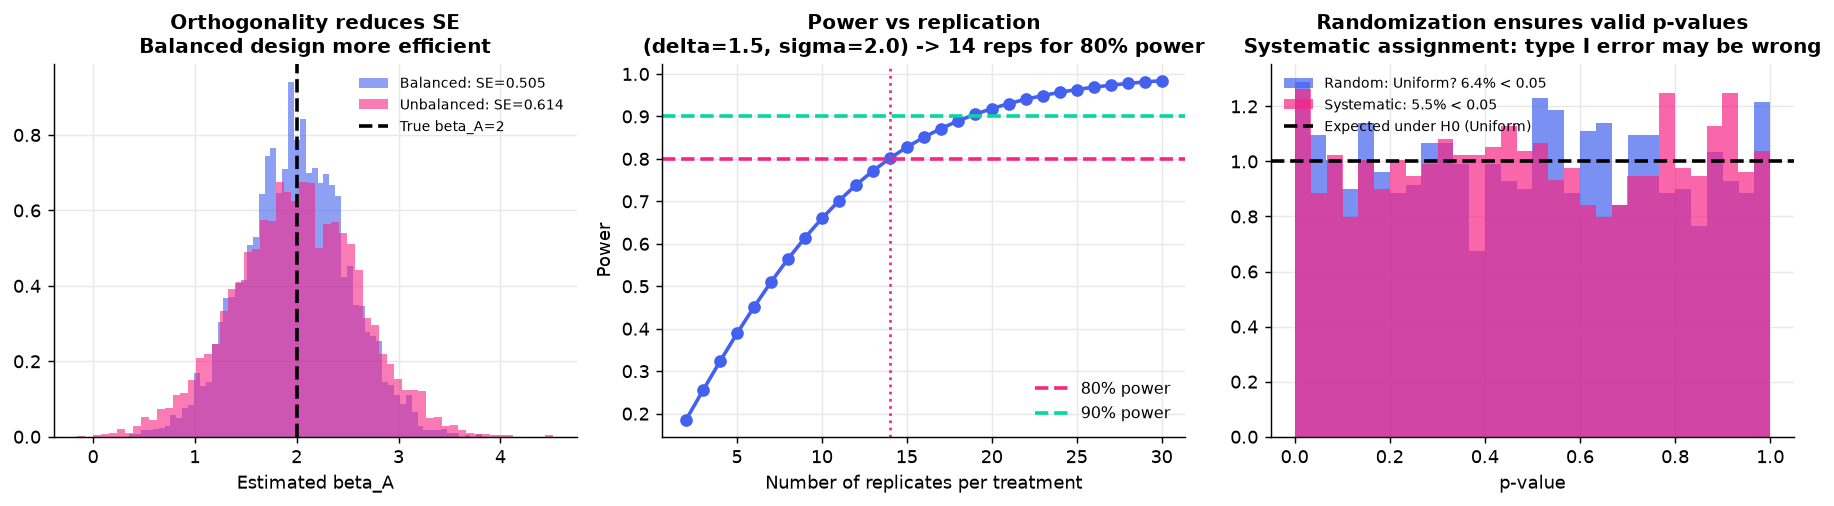

In [2]:
# ── Orthogonality: visual demonstration ──────────────────────────────────
# Design matrix for 2-factor, 2-level full factorial (balanced)
# Factors A, B each at -1 and +1
design_balanced = np.array([
    [-1, -1],
    [-1, +1],
    [+1, -1],
    [+1, +1],
], dtype=float)

# Unbalanced (non-orthogonal) design
design_unbalanced = np.array([
    [-1, -1],
    [-1, -1],   # duplicated
    [-1, +1],
    [+1, -1],
], dtype=float)

print('Orthogonality check: X_A^T X_B (should be 0 for orthogonal design)')
for name, D in [('Balanced 2^2', design_balanced), ('Unbalanced', design_unbalanced)]:
    XtX = D.T @ D
    corr_AB = XtX[0,1] / np.sqrt(XtX[0,0] * XtX[1,1])
    print(f'  {name:<20}: X_A.X_B = {D[:,0] @ D[:,1]:.0f}   corr(A,B) = {corr_AB:.4f}  {"ORTHOGONAL" if abs(corr_AB) < 1e-10 else "NOT orthogonal"}')

# ── Variance inflation from non-orthogonality ─────────────────────────────
# True model: Y = 2*A + 1.5*B + noise
# Compare estimation variance under balanced vs unbalanced design

B_sim = 5000
results = {'Balanced': [], 'Unbalanced': []}
for _ in range(B_sim):
    eps = np.random.normal(0, 1, 4)
    for name, D in [('Balanced', design_balanced), ('Unbalanced', design_unbalanced)]:
        X = sm.add_constant(D)
        y = 2*D[:,0] + 1.5*D[:,1] + eps
        try:
            b = np.linalg.lstsq(X, y, rcond=None)[0]
            results[name].append(b[1])   # estimate of beta_A
        except: pass

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'Balanced': '#4361ee', 'Unbalanced': '#f72585'}
for name, ests in results.items():
    axes[0].hist(np.array(ests), bins=60, alpha=0.6, density=True,
                 color=colors[name], label=f'{name}: SE={np.std(ests):.3f}')
axes[0].axvline(2.0, color='black', lw=2, linestyle='--', label='True beta_A=2')
axes[0].set_xlabel('Estimated beta_A'); axes[0].set_title('Orthogonality reduces SE\nBalanced design more efficient')
axes[0].legend(fontsize=8)

# ── Replication: power vs n_reps ──────────────────────────────────────────
from scipy.stats import norm as Normal
delta, sigma = 1.5, 2.0
alpha = 0.05
reps = np.arange(2, 31)
powers = [1 - Normal.cdf(Normal.ppf(1-alpha/2) - delta/(sigma/np.sqrt(r)))
          + Normal.cdf(-Normal.ppf(1-alpha/2) - delta/(sigma/np.sqrt(r)))
          for r in reps]
axes[1].plot(reps, powers, 'o-', color='#4361ee', lw=2)
axes[1].axhline(0.80, color='#f72585', lw=2, linestyle='--', label='80% power')
axes[1].axhline(0.90, color='#06d6a0', lw=2, linestyle='--', label='90% power')
r_80 = reps[np.argmax(np.array(powers) >= 0.80)]
axes[1].axvline(r_80, color='#f72585', lw=1.5, linestyle=':')
axes[1].set_xlabel('Number of replicates per treatment')
axes[1].set_ylabel('Power')
axes[1].set_title(f'Power vs replication\n(delta={delta}, sigma={sigma}) -> {r_80} reps for 80% power')
axes[1].legend(fontsize=9)

# ── Randomization: distribution of test stat under H0 ────────────────────
# Compare systematic vs random assignment
n_units = 20
true_effect = 0   # H0 true

def run_experiment(assignment_fn, B=2000):
    p_vals = []
    for _ in range(B):
        y = np.random.normal(0, 1, n_units)
        D = assignment_fn(n_units)
        t, p = stats.ttest_ind(y[D==1], y[D==0])
        p_vals.append(p)
    return np.array(p_vals)

# Random assignment
p_random = run_experiment(lambda n: np.array([1]*(n//2) + [0]*(n//2))[np.random.permutation(n)])
# Systematic: first half treated (could be confounded)
p_system = run_experiment(lambda n: np.array([1]*(n//2) + [0]*(n//2)))

axes[2].hist(p_random, bins=30, alpha=0.7, density=True, color='#4361ee', label=f'Random: Uniform? {np.mean(p_random<0.05)*100:.1f}% < 0.05')
axes[2].hist(p_system, bins=30, alpha=0.7, density=True, color='#f72585', label=f'Systematic: {np.mean(p_system<0.05)*100:.1f}% < 0.05')
axes[2].axhline(1.0, color='black', lw=2, linestyle='--', label='Expected under H0 (Uniform)')
axes[2].set_xlabel('p-value'); axes[2].set_title('Randomization ensures valid p-values\nSystematic assignment: type I error may be wrong')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Design vocabulary

| Term | Definition |
|---|---|
| **Factor** | A variable whose effect we want to study (e.g., temperature, dose, UI variant) |
| **Level** | A specific value of a factor (e.g., low/high, A/B/C) |
| **Treatment** | A combination of factor levels applied to an experimental unit |
| **Run** | A single execution of the experiment at a specific treatment combination |
| **Response** | The measured outcome (e.g., yield, conversion rate, revenue) |
| **Effect** | Change in the mean response caused by changing a factor |
| **Interaction** | When the effect of one factor depends on the level of another |
| **Confounding** | When two effects cannot be estimated separately from the data |
| **Resolution** | In fractional factorials: which effects are confounded with which (III, IV, V) |

## Variance decomposition in designed experiments

$$\text{SS}_{total} = \text{SS}_{treatments} + \text{SS}_{blocks} + \text{SS}_{error}$$

Each component captures a different source of variation:
- **SS treatments:** variation *caused* by different treatments
- **SS blocks:** variation *explained* by blocking factors (removed from error)
- **SS error:** unexplained residual variation — drives the SE of treatment estimates

The **blocking efficiency** is: $RE = 1 + \frac{\text{SS}_{blocks}}{\text{SS}_{error}}$ — how much
more efficient the blocked design is compared to a completely randomized design.

Blocking efficiency demonstration
True treatment effects: [0 3 6]

CRD  (ignores blocks): SE(beta_treat1) = 4.8966  MSE = 59.94
RCBD (uses blocks):    SE(beta_treat1) = 0.3038  MSE = 2.77

SS_blocks = 706.49
Relative efficiency (RCBD vs CRD) = 22.27
-> RCBD needs 4% of CRD sample size for same power


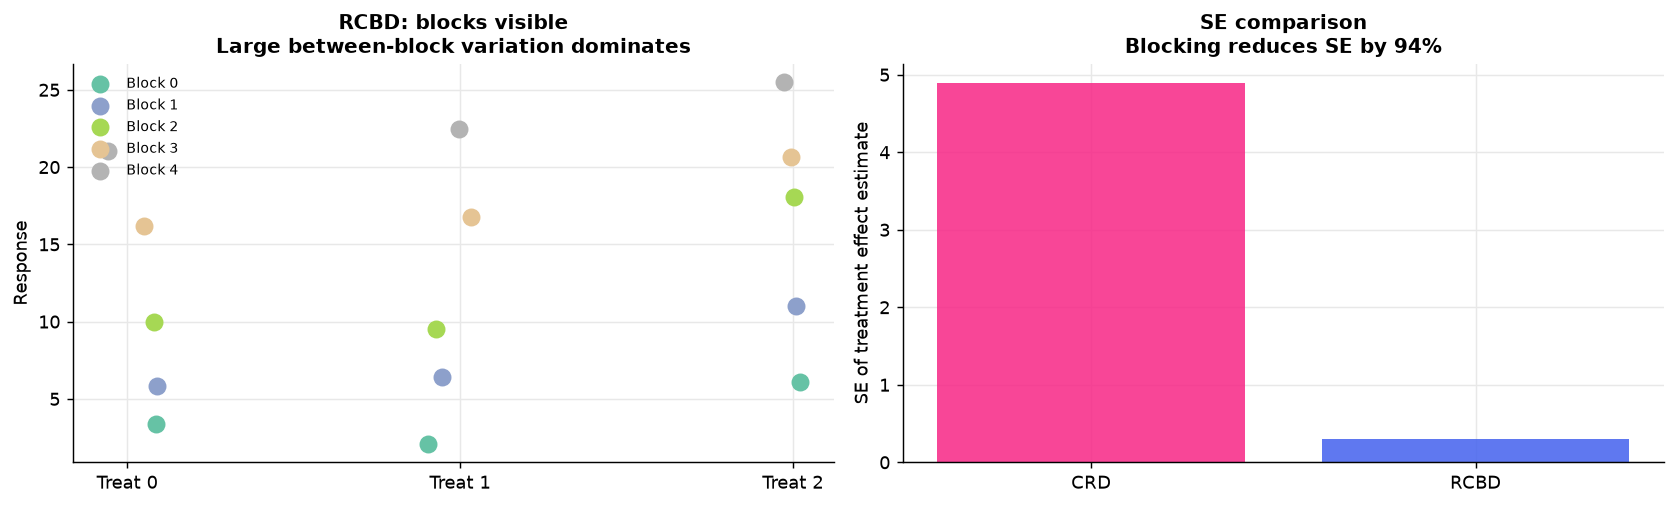

In [3]:
# ── Design efficiency: illustrate blocking gain ───────────────────────────
np.random.seed(7)
n_blocks = 5; n_treat = 3; r = 1   # RCBD: 5 blocks x 3 treatments
N = n_blocks * n_treat

# Block effect (the nuisance we're removing)
block_effects = np.array([0, 5, 10, 15, 20])   # large between-block variation
# Treatment effects
treat_effects = np.array([0, 3, 6])             # what we want to estimate

# Generate data
block_id = np.repeat(np.arange(n_blocks), n_treat)
treat_id = np.tile(np.arange(n_treat), n_blocks)
y = block_effects[block_id] + treat_effects[treat_id] + np.random.normal(0, 2, N)

df_exp = pd.DataFrame({'y': y, 'block': block_id, 'treat': treat_id})

# CRD analysis (ignores blocks)
X_crd = sm.add_constant(pd.get_dummies(df_exp['treat'], drop_first=True, dtype=float))
mod_crd = sm.OLS(y, X_crd).fit()

# RCBD analysis (includes blocks)
X_rcbd = pd.get_dummies(df_exp[['block','treat']], drop_first=True, dtype=float)
X_rcbd = sm.add_constant(X_rcbd)
mod_rcbd = sm.OLS(y, X_rcbd).fit()

print('Blocking efficiency demonstration')
print(f'True treatment effects: {treat_effects}')
print(f'\nCRD  (ignores blocks): SE(beta_treat1) = {mod_crd.bse.iloc[1]:.4f}  MSE = {mod_crd.mse_resid:.2f}')
print(f'RCBD (uses blocks):    SE(beta_treat1) = {mod_rcbd.bse.iloc[1]:.4f}  MSE = {mod_rcbd.mse_resid:.2f}')
ss_blocks = sum(n_treat*(df_exp.groupby('block')['y'].mean() - y.mean())**2)
ss_error_crd = mod_crd.ssr
re = 1 + ss_blocks/mod_rcbd.ssr
print(f'\nSS_blocks = {ss_blocks:.2f}')
print(f'Relative efficiency (RCBD vs CRD) = {re:.2f}')
print(f'-> RCBD needs {1/re*100:.0f}% of CRD sample size for same power')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_b = plt.cm.Set2(np.linspace(0, 1, n_blocks))
for b in range(n_blocks):
    mask = block_id == b
    axes[0].scatter(treat_id[mask] + np.random.uniform(-0.1,0.1, mask.sum()),
                    y[mask], color=colors_b[b], s=80, label=f'Block {b}', zorder=3)
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(['Treat 0','Treat 1','Treat 2'])
axes[0].set_ylabel('Response'); axes[0].set_title('RCBD: blocks visible\nLarge between-block variation dominates')
axes[0].legend(fontsize=8)

axes[1].bar(['CRD', 'RCBD'], [mod_crd.bse.iloc[1], mod_rcbd.bse.iloc[1]],
            color=['#f72585', '#4361ee'], alpha=0.85)
axes[1].set_ylabel('SE of treatment effect estimate')
axes[1].set_title(f'SE comparison\nBlocking reduces SE by {(1-mod_rcbd.bse.iloc[1]/mod_crd.bse.iloc[1])*100:.0f}%')
plt.tight_layout()
plt.show()